# Étape 2 : Prétraitement des Données (Data Preprocessing)
---

## Pipeline Preprocessing

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Imports | 1 | Charger `config.py` + librairies |
| Chargement | 2 | `data.csv` + `str.strip()` + `load_features()` |
| Copie de travail | 3 | Créer `df_proc` pour préserver `df` original |
| Qualité des données | 4 | NaN + doublons via `check_data_quality()` |
| Winsorization IQR | 5 | Écrêtage outliers sur `NUMERICAL_VARS` |
| Log1p | 6 | Correction skewness — variables avec `|skew| > 2` |
| Résumé | 7 | Tableau récapitulatif des étapes appliquées |
| Sauvegarde | 8 | `df_clean.csv` + vérification finale |

---

**Prérequis** : `1_EDA_Data_v2.ipynb` exécuté — génère `features.json`  
**Sortie** : `df_clean.csv` — chargé par `3_Modeling_v2.ipynb`|

## 1 Imports & Chargement config

In [1]:
import sys
sys.path.insert(0, './src')
import importlib, config
importlib.reload(config)
from config import (
    TARGET, RANDOM_STATE, DATA_PATH, CLEAN_PATH,
    check_data_quality, load_features
)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
print('Librairies importées avec succès !')

Librairies importées avec succès !


## 2. Chargement des données et des listes de variables

`load_features()` charge `CATEGORICAL_VARS` et `NUMERICAL_VARS` depuis `features.json`  
généré par l'EDA. `str.strip()` corrige le bug du nom de colonne `'alcohol '`.

In [ ]:
# Chargement du dataset brut
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
print(f'Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')

# Chargement des listes de variables depuis features.json
TARGET, CATEGORICAL_VARS, NUMERICAL_VARS, ALL_FEATURES = load_features()

Dataset chargé : 4603 lignes × 36 colonnes
features.json charge :
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables


## 2. Copie de travail

In [3]:
df_proc = df.copy()
print(f'Copie de travail créée : {df_proc.shape[0]} lignes × {df_proc.shape[1]} colonnes')

Copie de travail créée : 4603 lignes × 36 colonnes


## 4. Qualité des données — NaN + doublons

`check_data_quality()` importée de `config.py` — vérifie NaN et doublons en une seule fonction. Définie une fois, appelée dans chaque notebook.

In [4]:
is_clean = check_data_quality(df_proc)

if not is_clean:
    raise ValueError('Dataset non propre — corriger avant de continuer.')

  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 36 colonnes


## 4. Winsorization IQR — Traitement des outliers

L'EDA a quantifié les outliers par variable.
On applique l'écrêtage aux bornes `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

- Bornes calculées sur `df` **original** — pas sur `df_proc`
- Correction appliquée sur `df_proc`
- Sur `NUMERICAL_VARS` uniquement

In [5]:
outlier_report = []

for col in NUMERICAL_VARS:
    # Bornes calculées sur df ORIGINAL (avant toute modification)
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Compter outliers sur df ORIGINAL
    n_before = ((df[col] < lower) | (df[col] > upper)).sum()

    if n_before > 0:
        # Appliquer correction sur df_proc
        df_proc[col] = df_proc[col].clip(lower=lower, upper=upper)
        outlier_report.append({
            'Variable'      : col,
            'Outliers avant': n_before,
            '% avant'       : f'{n_before / len(df) * 100:.2f}%',
            'Borne lower'   : round(lower, 3),
            'Borne upper'   : round(upper, 3),
        })

if outlier_report:
    print(f'Winsorization appliquée sur {len(outlier_report)} variable(s) :')
    display(pd.DataFrame(outlier_report))
else:
    print('Aucun outlier détecté — aucune Winsorization nécessaire.')

Winsorization appliquée sur 20 variable(s) :


,Variable,Outliers avant,% avant,Borne lower,Borne upper
0,sleep time,63,1.37%,3.000,11.000
1,Minutes sedentary activity,79,1.72%,-120.000,840.000
2,Waist Circumference,82,1.78%,64.750,146.750
3,Systolic blood pressure,97,2.11%,84.000,180.000
4,Diastolic blood pressure,50,1.09%,40.000,104.000
5,High-density lipoprotein,113,2.45%,0.250,2.330
6,Triglyceride,268,5.82%,-0.006,3.058
7,Low-density lipoprotein,47,1.02%,0.707,5.133
8,Fasting Glucose,532,11.56%,3.790,8.651
9,Glycohemoglobin,410,8.91%,4.050,7.650


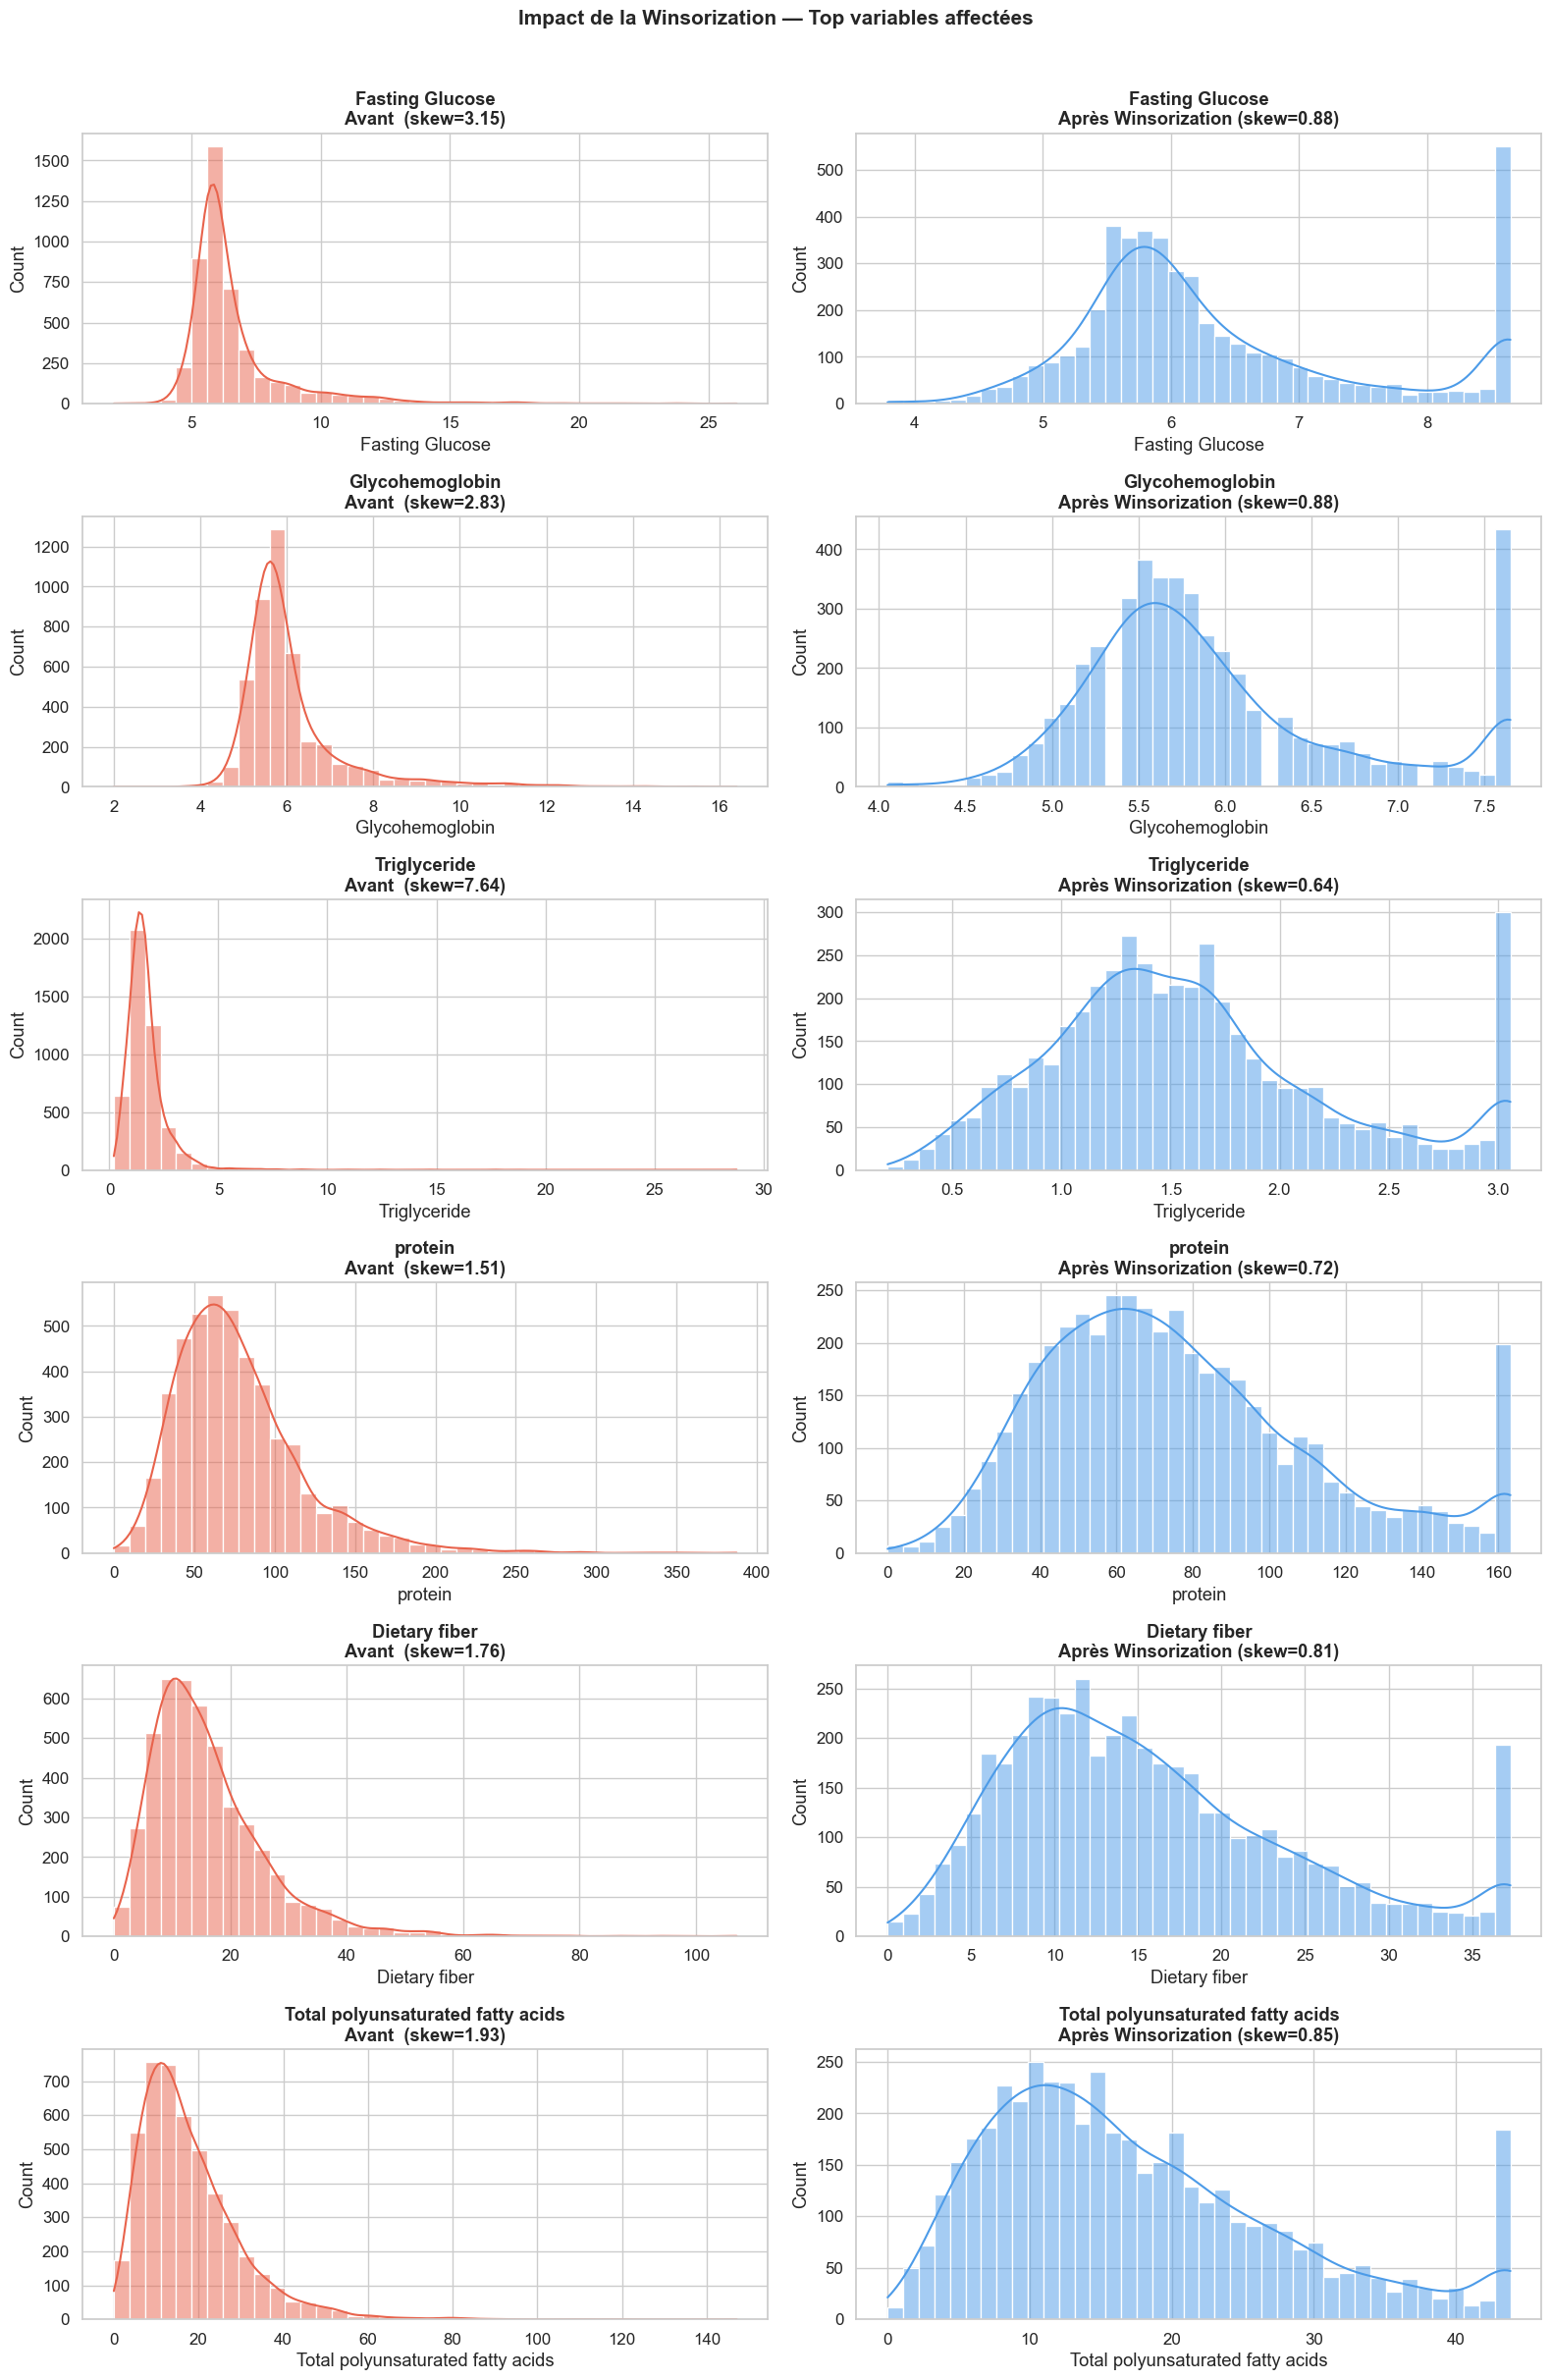

In [6]:
if outlier_report:
    top_cols = pd.DataFrame(outlier_report).nlargest(6, 'Outliers avant')['Variable'].tolist()

    fig, axes = plt.subplots(len(top_cols), 2, figsize=(16, 4 * len(top_cols)))
    if len(top_cols) == 1:
        axes = [axes]

    for i, col in enumerate(top_cols):
        sns.histplot(df[col], ax=axes[i][0], kde=True,
                     color='#E8634C', bins=40, edgecolor='white')
        axes[i][0].set_title(f"{col}\nAvant  (skew={df[col].skew():.2f})",
                             fontweight='bold')

        sns.histplot(df_proc[col], ax=axes[i][1], kde=True,
                     color='#4C9BE8', bins=40, edgecolor='white')
        axes[i][1].set_title(f"{col}\nAprès Winsorization (skew={df_proc[col].skew():.2f})",
                             fontweight='bold')

    plt.suptitle("Impact de la Winsorization — Top variables affectées",
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Pas de visualisation — aucun outlier traité")

## 5. Transformation Logarithmique — Variables Skewed

L'EDA a identifié 3 variables avec `|skewness| > 2` :
- `Triglyceride` → skewness = 7.64
- `Fasting Glucose` → skewness = 3.15
- `Glycohemoglobin` → skewness = 2.83

On applique `np.log1p` (= log(x+1)) pour éviter `log(0)` indéfini.

> Cette transformation réduit l'asymétrie et atténue également l'effet des outliers résiduels.

In [7]:
# Identifier les variables encore skewed après Winsorization
skewed_vars = [
    col for col in NUMERICAL_VARS
    if abs(df_proc[col].skew()) > 2
]

print(f'Variables à transformer ({len(skewed_vars)}) :')
for col in skewed_vars:
    print(f'   {col:<40} skewness = {df_proc[col].skew():.2f}')

# Application Log1p
for col in skewed_vars:
    df_proc[col] = np.log1p(df_proc[col])

print('\nSkewness après log1p :')
for col in skewed_vars:
    print(f'{col:<40} skewness finale = {df_proc[col].skew():.2f}')

if not skewed_vars:
    print('Aucune variable avec |skewness| > 2 — log1p non nécessaire.')

Variables à transformer (0) :

Skewness après log1p :
Aucune variable avec |skewness| > 2 — log1p non nécessaire.


In [8]:
if skewed_vars:
    n_cols_plot = len(skewed_vars)
    fig, axes = plt.subplots(n_cols_plot, 2, figsize=(16, 4 * n_cols_plot))

    if n_cols_plot == 1:
        axes = [axes]

    for i, col in enumerate(skewed_vars):
        sns.histplot(
            df[col],
            ax=axes[i][0],
            kde=True,
            color="#E8634C",
            bins=40,
            edgecolor="white",
        )
        axes[i][0].set_title(
            f"{col}\nBrut — skew={df[col].skew():.2f}",
            fontweight="bold"
        )

        sns.histplot(
            df_proc[col],
            ax=axes[i][1],
            kde=True,
            color="#27AE60",
            bins=40,
            edgecolor="white",
        )
        axes[i][1].set_title(
            f"{col}\nAprès log1p — skew={df_proc[col].skew():.2f}",
            fontweight="bold"
        )

    plt.suptitle(
        "Transformation Logarithmique — Réduction de l'Asymétrie",
        fontsize=15,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

else:
    print("Aucune variable avec |skewness| > 2 détectée sur le dataset original.")
    print("→ Pas de transformation log1p nécessaire.")

Aucune variable avec |skewness| > 2 détectée sur le dataset original.
→ Pas de transformation log1p nécessaire.


## 6. Résumé du pipeline preprocessing

In [9]:
summary = pd.DataFrame({
    'Étape': [
        '4. Qualité données',
        '5. Winsorization IQR',
        '6. Log1p',
    ],
    'Action / Résultat': [
        f'0 NaN, 0 doublon -> aucune action',

        f'Écrêtage sur {len(outlier_report)} variable(s) — 0 ligne perdue',

        f'log1p sur {len(skewed_vars)} variable(s) (seuil |skew| > 2)',
    ],
    'Shape': [
        str(df.shape),
        str(df_proc.shape),
        str(df_proc.shape),
    ]
})

display(summary.style.hide(axis='index'))
print(f'Shape final    : {df_proc.shape}')
print(f'NaN restants   : {df_proc.isnull().sum().sum()}')
print(f'Doublons rest. : {df_proc.duplicated().sum()}')

Étape,Action / Résultat,Shape
4. Qualité données,"0 NaN, 0 doublon -> aucune action","(4603, 36)"
5. Winsorization IQR,Écrêtage sur 20 variable(s) — 0 ligne perdue,"(4603, 36)"
6. Log1p,log1p sur 0 variable(s) (seuil |skew| > 2),"(4603, 36)"


Shape final    : (4603, 36)
NaN restants   : 0
Doublons rest. : 0


## 7. Sauvegarde — `df_clean.csv`

In [10]:
output_dir = '../dataset/data_clean/'
os.makedirs(output_dir, exist_ok=True)

df_proc.to_csv(output_dir + 'df_clean.csv', index=False)

# Vérification finale
df_check = pd.read_csv(output_dir + 'df_clean.csv')
print('df_clean.csv sauvegardé avec succès !')
print(f'  Shape    : {df_check.shape}')
print(f'  NaN      : {df_check.isnull().sum().sum()}')
print(f'  Doublons : {df_check.duplicated().sum()}')
print()
print('Preprocessing V2 terminé.')

df_clean.csv sauvegardé avec succès !
  Shape    : (4603, 36)
  NaN      : 0
  Doublons : 0

Preprocessing V2 terminé.
